# FULMAR: Follow-Up Lightcurves Multitool Assisting Radial-velocities

This notebook demonstrates the core FULMAR workflow for light curve analysis and transit search. It serves as a companion to Chapter 3 of the thesis. 

**Usage:** set your target in the `Target` section below, then run all cells in order.

**Requirements:** `lightkurve`, `wotan`, `transitleastsquares` (Talens fork), `PyTransit`, `ldtk`, `astroquery`, `astropy`

## Imports

In [1]:
import os
import json
import warnings

from astropy.time import Time
import astropy.units as u

import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
import wotan as wt

from astropy.coordinates import Angle, SkyCoord
from astropy.io.ascii import convert_numpy
from astropy.stats import mad_std
from astropy.table import Table, vstack

from astroquery.gaia import Gaia
from astroquery.mast import Catalogs

from collections import OrderedDict

from ldtk import LDPSetCreator, SVOFilter

from transitleastsquares import transit_mask, transitleastsquares # Use Geert Jan Talens implemetation https://github.com/talensgj/tls

from pytransit import BaseLPF

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


## Helper functions

### JSON encoder for numpy types

In [2]:
# import json
class NumpyEncoder(json.JSONEncoder):
    """
    Special json encoder for numpy types.
    """
    def default(lpf, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        return json.JSONEncoder.default(lpf, obj)

### Time utilities

In [3]:
def to_btjd(t):
    """
    Convert a date string to BTJD (BJD - 2457000, scale='tdb').
    Accepts BTJD float string, BJD float string, or ISO/ISOT UTC string.
    """
    try:
        val = float(t)
        if val > 2457000:                        # BJD -> BTJD
            return Time(val, format='jd', scale='tdb').btjd
        else:                                    # Already BTJD
            return val
    except (ValueError, TypeError):             # ISO/ISOT string
        return Time(t, scale='utc').tdb.btjd
  
def sectors_in_date_range(lc_col, date_start, date_end):
    """
    Return indices into lc_col for sectors overlapping the given date range.
    date_start or date_end can be None to indicate no lower/upper bound.
    """
    t_start = to_btjd(date_start)
    t_end   = to_btjd(date_end)
    return [i for i, lc in enumerate(lc_col)
            if (t_start is None or lc.time.btjd.max() >= t_start)
            and (t_end   is None or lc.time.btjd.min() <= t_end)]


### Light curve utilities

In [4]:
def find_longest_consecutive_sequence(arr, tolerance=0):
    """
    Finds the longest consecutive sequence inside an array with
    a given gap tolerance. Used to select TESS sectors
    
    Args:
        arr (np.array): Observed sectors
        tolerance (int, optional): Max allowed missing sectors. Ex: [1, 2, 4] 
    
    """
    if len(arr) == 0:
        return None, None, None
    
    if len(arr) == 1:
        return arr, 0, 0
    
    # Find where consecutive differences are within tolerance
    diffs = np.diff(arr)-1

    is_consecutive = diffs <= tolerance

    # Pad with False at start and end to detect boundaries
    is_consecutive_padded = np.concatenate(([False], is_consecutive, [False]))
    
    # Find boundaries: where we transition from False to True (starts)
    # and from True to False (ends)
    transitions = np.diff(is_consecutive_padded.astype(int))
    
    starts = np.where(transitions == 1)[0]
    ends = np.where(transitions == -1)[0]
    
    if len(starts) == 0:
        # No consecutive sequences found
        return arr[0:1], 0, 0
    
    # Calculate lengths - ends already point one past the last True
    lengths = ends - starts + 1  # +1 because we include both start and end elements
    
    # Find the longest sequence
    max_idx = np.argmax(lengths)
    start_idx = starts[max_idx]
    end_idx = ends[max_idx]  # This is already one past the last element in the sequence

    consecutive_array = arr[start_idx:end_idx + 1]
    
    return consecutive_array, start_idx, end_idx

In [5]:
# from astropy.stats import mad_std
def sigma_clip_mask(flux, sigma_upper=5, sigma_lower=5):
    """
    Remove outliers while preserving sequences of 3+ consecutive low points.
    
    Parameters
    ----------
    flux : array-like
        Flux values
    sigma_upper : float
        Sigma threshold for upper outliers
    sigma_lower : float
        Sigma threshold for lower outliers
        
    Returns
    -------
    mask : boolean array
        True for points to keep, False for outliers
    """
    flux = np.array(flux)
    median = np.median(flux)
    sigma = mad_std(flux) # Standard deviation = 1.4826 * MAD for gaussian distributions
    
    # Identify outliers
    upper_outliers = flux > (median + sigma_upper * sigma)
    lower_outliers = flux < (median - sigma_lower * sigma)
    
    # Find consecutive sequences of lower outliers
    # Pad with False to handle edges
    lower_padded = np.concatenate(([False], lower_outliers, [False]))
    
    # Find start and end of consecutive sequences
    diff = np.diff(lower_padded.astype(int))
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]
    
    # Keep lower outliers that are part of 3+ consecutive sequences
    keep_lower = np.zeros_like(lower_outliers)
    for start, end in zip(starts, ends):
        if (end - start) >= 3:  # 3 or more consecutive
            keep_lower[start:end] = True
    
    # Remove upper outliers and isolated lower outliers
    mask = ~upper_outliers & (~lower_outliers | keep_lower)
    
    return mask

In [6]:
def time_flux_err(
        timeseries,
        flux_kw='flux',
        flux_err_kw='flux_err',
        replace_nan_err=True):
    """Extracts 3 arrays with time, flux and flux_err from a TimeSeries.

    Parameters
    ----------
    timeseries : `~astropy.timeseries.TimeSeries`
        TimeSeries object
    flux_kw : str, optional
        Keyword for the column containing the flux values
        (Default: 'flux')
    flux_err_kw : str, optional
        Keyword for the column containing the flux uncertainty values
        (Default: 'flux_err')
    replace_nan_err : bool, optional
        To deal with the case where the flux_err column is full
        of NaNs. When True, creates an array filled with the standard
        deviation of the flux. When false, returns an array full of NaNs.
        (default : True)

    Returns
    -------
    t : array
        Array of time where values of type NaN, None, inf, and negative
        have been removed, as well as masks.
    flux : array
        Array of flux where values of type NaN, None, inf, and negative
        have been removed, as well as masks.
    flux_err : array
        Array of flux_err where values of type NaN, None, inf,
        and negative have been removed, as well as masks.
        If the original was filled with NaNs: if replace_nan_err=True,
        returns an array filled with the standard deviation of flux.
        if replace_nan_err=False, returns an array filled with Nans.
    """
    t = timeseries.time.value
    flux = np.array(timeseries[flux_kw], dtype=np.float64)
    flux_err = np.array(timeseries[flux_err_kw], dtype=np.float64)

    t = np.ascontiguousarray(t)
    flux = np.ascontiguousarray(flux)
    flux_err = np.ascontiguousarray(flux_err)
    
    # The case where flux_err has Nan
    if np.isnan(np.sum(flux_err)):
        if replace_nan_err is True:
            flux_err = np.full_like(flux, mad_std(flux))
        else:
            flux_err = np.nan * flux


    return t, flux, flux_err

In [86]:
def bin_lc(timeseries, bin_size, flux_kw='flux', flux_err_kw='flux_err'):
    """
    Bin a light curve. Flux is medianed, errors combined in quadrature.
    Returns an object of the same type as the input.
 
    Parameters
    ----------
    timeseries : astropy TimeSeries or lightkurve LightCurve
        Input light curve.
    bin_size : float or astropy Quantity
        Bin size. If a float, interpreted as days. If an astropy Quantity,
        converted to days automatically (e.g. 4*u.h).
    flux_kw : str
        Column name for flux (default: 'flux').
    flux_err_kw : str
        Column name for flux error (default: 'flux_err').
 
    Returns
    -------
    Same type as input, with binned time, flux, and flux_err columns.
    """
    from astropy.timeseries import TimeSeries
    from astropy.time import Time
 
    # Convert bin_size to days
    if hasattr(bin_size, 'to'):
        bin_size_days = bin_size.to(u.d).value
    else:
        bin_size_days = float(bin_size)
 
    t, flux, err = time_flux_err(timeseries, flux_kw=flux_kw, flux_err_kw=flux_err_kw)
 
    bins = np.arange(t.min(), t.max() + bin_size_days, bin_size_days)
    idx  = np.digitize(t, bins)
 
    t_bin, f_bin, e_bin = [], [], []
    for i in range(1, len(bins)):
        mask = idx == i
        if mask.sum() == 0:
            continue
        t_bin.append(np.nanmedian(t[mask]))
        f_bin.append(np.nanmedian(flux[mask]))
        n = np.sum(np.isfinite(err[mask]))
        e_bin.append(np.sqrt(np.nansum(err[mask]**2)) / n if n > 0 else np.nan)
 
    t_bin = np.array(t_bin)
    f_bin = np.array(f_bin)
    e_bin = np.array(e_bin)
 
    # Reconstruct as the same type as input
    time_obj = Time(t_bin, format=timeseries.time.format,
                    scale=timeseries.time.scale)
 
    import lightkurve as lk
    if isinstance(timeseries, lk.LightCurve):
        result = lk.LightCurve(time=time_obj,
                                data={flux_kw: f_bin, flux_err_kw: e_bin})
        result.flux     = result[flux_kw]
        result.flux_err = result[flux_err_kw]
    else:
        result = TimeSeries(time=time_obj,
                            data={flux_kw: f_bin, flux_err_kw: e_bin})
 
    return result

### Plotting utilities

In [7]:
def tls_plotter(tls_result, maxper=None, title=None, savefig=False, outdir=None):
    """
    Plots the result of a TLS periodogram, highlighting aliases.
    """
    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    ax.axvline(tls_result['period'], alpha=0.4, lw=3, color='xkcd:green')
    plt.xlim(np.min(tls_result['periods']), np.max(tls_result['periods']))
    for n in range(2, 30):
        ax.axvline(n*tls_result['period'], alpha=0.4, lw=1, linestyle="dashed", color='xkcd:vibrant green')
        ax.axvline(tls_result['period'] / n, alpha=0.4, lw=1, linestyle="dashed", color='xkcd:vibrant green')
    plt.ylabel(r'SDE', fontsize=14)
    plt.xlabel('Period (days)', fontsize=14)
    #plt.ylim(0, 1.2*tls_result['SDE'])
    ax.text(.02, .95, str("SDE = {0:.2f}, best period = {1:.5f} days".format(
                 tls_result['SDE'], tls_result['period'])), transform=ax.transAxes, fontsize=12, backgroundcolor='white')
    #plt.annotate("SDE = {0:.2f}, best period = {1:.5f} days".format(
    #             tls_result['SDE'], tls_result['period']),
    #             (.02, .95),
    #             xycoords="axes fraction",
    #             fontsize=12)
    plt.plot(tls_result['periods'], tls_result['power'], color='black', lw=0.5)
    plt.ylim(0, min(tls_result['SDE']+5, 1.2*tls_result['SDE']))
    if maxper is not None:
        plt.xlim(0,maxper)
    if title is not None:
        plt.title(title, fontsize=16)
    if savefig is True:
        if outdir is None:
            plt.savefig(
                str(title).replace(" ","_").replace(".","-")+".png", facecolor='white', dpi=240)
        else:
            try:
                os.makedirs(outdir)
            except FileExistsError:
                # directory already exists
                #print("directory already exists")
                pass

            plt.savefig(
                outdir+"/"+str(title).replace(" ","_").replace(".","-")+".png", facecolor='white', dpi=240)
#plt.xlim(0, 40);

In [8]:
def fold(time, period, origo=0.0, shift=0.0, normalize=True, clip_range=None):
    """Folds the given data over a given period.

    Parameters
    ----------
    
      time        
      period      
      origo       
      shift       
      normalize   
      clip_range  

    Returns
    -------

      phase       
    """
    tf = ((time - origo)/period + shift) % 1.
    if not normalize:
        tf *= period
        
    if clip_range is not None:
        mask = np.logical_and(clip_range[0]<tf, tf<clip_range[1])
        tf = tf[mask], mask
    return tf

In [9]:
def downsample_time(time, vals, inttime=1.):
    """
    Time binning used for the phase-folded data
    """
    duration = time.max() - time.min()
    nbins = int(np.ceil(duration / inttime))
    bins = np.arange(nbins)
    edges = time[0] + bins * inttime
    bids = np.digitize(time, edges) - 1
    bt, bv, be = np.full(nbins, np.nan), np.zeros(nbins), np.zeros(nbins)
    for i, bid in enumerate(bins):
        bmask = bid == bids
        if bmask.sum() > 0:
            bt[i] = time[bmask].mean()
            bv[i] = vals[bmask].mean()
            if bmask.sum() > 2:
                be[i] = vals[bmask].std() / np.sqrt(bmask.sum())
            else:
                be[i] = np.nan
    m = np.isfinite(be)
    return bt[m], bv[m], be[m]


In [10]:
def plot_folded_transit(lpf, method='median', figsize=(8, 6), ylim=(0.9975, 1.002), xlim=None, binwidth=20,
                        offset=0):
    """
    Method used to plot transits from an pytransit lpf
    """
    if method == 'de':
        pv = lpf.de.minimum_location
        tc, p = pv[[0, 1]]
    elif method == 'median':
        pv = lpf.posterior_samples().median()
        tc, p = pv[['tc', 'p']]
    else:
        raise NotImplementedError

    phase = p * fold(lpf.timea, p, tc, 0.5)
    binwidth = binwidth / 24 / 60
    sids = np.argsort(phase)

    tm = lpf.transit_model(pv)


    bp, bfo, beo = downsample_time(phase[sids], (lpf.ofluxa)[sids], binwidth)
    
#    print(np.median(tm)-np.median(bfo))
#    print(np.median(lpf.ofluxa)-np.median(tm))    
#    print(np.median(lpf.ofluxa)-np.median(bfo))
#    print(offset)

    fig, ax = plt.subplots(figsize=figsize)
    SMALL_SIZE = 14
    MEDIUM_SIZE = 16
    BIGGER_SIZE = 18
    
    plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
    plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
    plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
    plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
    plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
    plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
    plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
    
    ax.errorbar(phase - 0.5 * p, lpf.ofluxa, lpf.errora, fmt='o', color='xkcd:grey', ecolor='xkcd:silver', markersize=2, alpha = 1, lw=.5,zorder=1)
    # ax.plot(phase - 0.5 * p, lpf.ofluxa / bl, '.', color='xkcd:grey', markersize=3.5, alpha = 1, lw=.4)
    ax.errorbar(bp - 0.5 * p, bfo, beo, fmt='o', ms=6, color="xkcd:tree green",zorder=3)#, markeredgecolor='C1')
    ax.plot(phase[sids] - 0.5 * p, tm[sids], color='xkcd:black', lw=2.5, alpha=1, zorder=2) #color='xkcd:vibrant green')
    #ax.plot(phase[sids] - 0.5 * p, fm[sids], color='xkcd:vibrant green', lw=2.5, alpha=1, zorder=2)    
    xlim = xlim if xlim is not None else 1.01 * (bp[np.isfinite(bp)][[0, -1]] - 0.5 * p)
    # ylim = ylim if ylim is not None else (min(lpf.ofluxa)-0.01*(max(lpf.ofluxa)-min(lpf.ofluxa)), max(lpf.ofluxa)+0.01*(max(lpf.ofluxa)-min(lpf.ofluxa)))
    ylim = ylim if ylim is not None else (min(lpf.ofluxa), max(lpf.ofluxa))
    # print(ylim)
    plt.setp(ax, ylim=ylim, xlim=xlim, xlabel='Time - Tc [d]', ylabel='Normalised flux')
    plt.title(f"{lpf.name} phase folded at {p:.3f} d")
    #ax.title.set_fontsize(18)
    
    fig.tight_layout()    
    return fig

### Planet parameter estimators

These functions estimate the planet mass from its radius using empirical mass-radius relations, and the expected RV semi-amplitude $K$ from the planet mass and orbital parameters.

In [11]:
def estimate_planet_mass(
        R_p,
        R_p_err=None,
        rho_p='rocky'):
    """
    Estimates the mass of an exoplanet from its radius and density.

    Parameters
    ----------
    R_p : `~astropy.units.Quantity` or float
        Radius of the exoplanet. (defaults to units of Earth radii)
    R_p_err : `~astropy.units.Quantity` or float, optional
        Uncertainty in radius (defaults to units of Earth radii)
    rho_p : `~astropy.units.Quantity`, float or str
        Density of the exoplanet in kg * m^-3. Can be "iron", "rocky",
        "neptune", "jupiter", or "puffy". Default: "rocky"

    Returns
    -------
    M_planet : `~astropy.units.Quantity`
        Estimated mass of the exoplanet.
    M_planet_err : `~astropy.units.Quantity` or None
        Uncertainty in mass (if R_p_err provided)
    """
    # Physically motivated density dictionary
    dens_dic = {
        'iron': 7874 * (u.kg / u.m**3),      # Pure iron core
        'rocky': 5500 * (u.kg / u.m**3),     # Rocky/iron-silicate (Earth-like)
        'neptune': 1640 * (u.kg / u.m**3),   # Ice giant (Neptune/Uranus)
        'jupiter': 1330 * (u.kg / u.m**3),   # Gas giant (Jupiter/Saturn-like)
        'puffy': 300 * (u.kg / u.m**3),      # Inflated hot Jupiter
    }

    if isinstance(R_p, (int, float)):
        R_p = R_p * u.earthRad
    elif isinstance(R_p, u.Quantity):
        R_p = R_p.to(u.earthRad)
    else:
        raise TypeError('R_p should be `astropy.units.Quantity` or float')

    if R_p_err is not None:
        if isinstance(R_p_err, (int, float)):
            R_p_err = R_p_err * u.earthRad
        elif isinstance(R_p_err, u.Quantity):
            R_p_err = R_p_err.to(u.earthRad)

    if isinstance(rho_p, (int, float)):
        rho_p = rho_p * (u.kg / u.m**3)
    elif isinstance(rho_p, str):
        if rho_p.lower() in dens_dic.keys():
            rho_p = dens_dic[rho_p.lower()]
        else:
            raise ValueError(
                f'Accepted str values for rho_p are: {list(dens_dic.keys())}')
    elif not isinstance(rho_p, u.Quantity):
        raise TypeError(
            'rho_p should be `astropy.units.Quantity`, float or str.')

    # M = (4/3) * pi * R^3 * rho = R^3 * rho / rho_Earth * M_Earth
    earth_density = 5514 * (u.kg / u.m**3)
    M_planet = (R_p.value ** 3 * rho_p / earth_density) * u.earthMass
    
    # Error propagation: M ~ R^3, so sigma_M/M = 3 * sigma_R/R
    if R_p_err is not None:
        M_planet_err = M_planet.value * 3 * (R_p_err.value / R_p.value) * u.earthMass
        return M_planet, M_planet_err
    
    return M_planet, None

In [12]:
def estimate_semi_amplitude(
        period,
        M_star=1*u.solMass,
        period_err=None,
        M_star_err=None,
        M_planet=None,
        M_planet_err=None,
        R_planet=None,
        R_planet_err=None,
        rho_planet='rocky',
        inc=90 * u.deg,
        inc_err=None,
        ecc=0):
    """
    Estimates the radial velocity semi-amplitude corresponding to a planet of
    given parameters.

    Parameters
    ----------
    period : `~astropy.units.Quantity` or float
        The period to use for folding. (defaults to units of days)
    M_star : `~astropy.units.Quantity` or float
        Stellar mass (defaults to units of solar masses)
    period_err : `~astropy.units.Quantity` or float, optional
        Uncertainty in period (defaults to units of days)
    M_star_err : `~astropy.units.Quantity` or float, optional
        Uncertainty in stellar mass (defaults to units of solar masses)
    M_planet : `~astropy.units.Quantity` or float, optional
        Mass of the exoplanet. (defaults to units of Earth masses)
    M_planet_err : `~astropy.units.Quantity` or float, optional
        Uncertainty in planet mass (defaults to units of Earth masses)
    R_planet : `~astropy.units.Quantity` or float, optional
        Radius of the exoplanet. (defaults to units of Earth radii)
    R_planet_err : `~astropy.units.Quantity` or float, optional
        Uncertainty in planet radius (defaults to units of Earth radii)
    rho_planet : `~astropy.units.Quantity`, float or str
        Density of the exoplanet in kg * m^-3. Can be "rocky", "neptune",
        "jupiter", or "puffy". Default: "rocky"
    inc : `~astropy.units.Quantity` or float
        Orbital inclination (in degrees). Default: 90.
    inc_err : `~astropy.units.Quantity` or float, optional
        Uncertainty in inclination (in degrees)
    ecc : float
        Orbital eccentricity. Default: 0.

    Returns
    -------
    K : `~astropy.units.Quantity`
        Estimated semi-amplitude of the RV.
    K_err : `~astropy.units.Quantity` or None
        Uncertainty in semi-amplitude (if errors provided)
    """
    if isinstance(period, (int, float)):
        period = period * u.d
    elif not isinstance(period, u.Quantity):
        raise TypeError(
            'period should be `astropy.units.Quantity` or float')

    if period_err is not None:
        if isinstance(period_err, (int, float)):
            period_err = period_err * u.d
        elif not isinstance(period_err, u.Quantity):
            raise TypeError(
                'period_err should be `astropy.units.Quantity` or float')

    if isinstance(M_star, (int, float)):
        M_star = M_star * u.solMass
    elif not isinstance(M_star, u.Quantity):
        raise TypeError(
            'M_star should be `astropy.units.Quantity` or float')

    if M_star_err is not None:
        if isinstance(M_star_err, (int, float)):
            M_star_err = M_star_err * u.solMass
        elif not isinstance(M_star_err, u.Quantity):
            raise TypeError(
                'M_star_err should be `astropy.units.Quantity` or float')

    if isinstance(inc, (int, float)):
        inc = inc * u.deg
    elif not isinstance(inc, u.Quantity):
        raise TypeError(
            'inc should be `astropy.units.Quantity` or float')

    if inc_err is not None:
        if isinstance(inc_err, (int, float)):
            inc_err = inc_err * u.deg
        elif not isinstance(inc_err, u.Quantity):
            raise TypeError(
                'inc_err should be `astropy.units.Quantity` or float')

    if M_planet is None:
        if R_planet is None or rho_planet is None:
            raise ValueError('R_planet and rho_planet are both required '
                             'when M_planet is not given')
        else:
            M_planet, M_planet_err = estimate_planet_mass(
                R_planet, R_planet_err, rho_planet)
    else:
        if R_planet is not None or rho_planet is not None:
            warnings.warn(
                'M_planet overrides R_planet and rho_planet')#, FulmarWarning)

        if isinstance(M_planet, (int, float)):
            M_planet = M_planet * u.earthMass
        elif not isinstance(M_planet, u.Quantity):
            raise TypeError(
                'M_planet should be `astropy.units.Quantity` or float')

        if M_planet_err is not None:
            if isinstance(M_planet_err, (int, float)):
                M_planet_err = M_planet_err * u.earthMass
            elif not isinstance(M_planet_err, u.Quantity):
                raise TypeError(
                    'M_planet_err should be `astropy.units.Quantity` or float')

    inc = inc.to(u.deg)

    M_p_jovian = M_planet.to(u.jupiterMass).value
    M_tot_solar = (M_star + M_planet).to(u.solMass).value

    # Equation (14) from Lovis & Fischer 2010
    # K = 28.4329 m/s * M_p * sin(i) * M_tot^(-2/3) * P^(-1/3) / sqrt(1 - e)
    K = 28.4329 * (u.m / u.s) * \
        M_p_jovian * \
        np.sin(inc) * np.power(M_tot_solar, -2 / 3) * \
        np.power(period.to(u.year).value, -1 / 3) / np.sqrt(1 - ecc)

    # Error propagation: K ~ M_p * sin(i) * M_tot^(-2/3) * P^(-1/3)
    if any(err is not None for err in [M_planet_err, M_star_err, period_err, inc_err]):
        rel_err_sq = 0
        
        # dK/dM_p: K ~ M_p -> (sigma_Mp/Mp)^2
        if M_planet_err is not None:
            M_p_jovian_err = M_planet_err.to(u.jupiterMass).value
            rel_err_sq += (M_p_jovian_err / M_p_jovian) ** 2
        
        # dK/dM_star: K ~ M_tot^(-2/3) -> (-2/3 * sigma_Ms/M_tot)^2
        # Approximation: M_tot ~ M_star for most cases
        if M_star_err is not None:
            M_star_solar = M_star.to(u.solMass).value
            M_star_solar_err = M_star_err.to(u.solMass).value
            rel_err_sq += (2/3 * M_star_solar_err / M_star_solar) ** 2
        
        # dK/dP: K ~ P^(-1/3) -> (-1/3 * sigma_P/P)^2
        if period_err is not None:
            period_year = period.to(u.year).value
            period_year_err = period_err.to(u.year).value
            rel_err_sq += (1/3 * period_year_err / period_year) ** 2
        
        # dK/di: K ~ sin(i) -> (cos(i) * sigma_i / sin(i))^2
        if inc_err is not None:
            inc_rad = inc.to(u.rad).value
            inc_rad_err = inc_err.to(u.rad).value
            if np.sin(inc_rad) > 0:  # Avoid division by zero
                rel_err_sq += (np.cos(inc_rad) * inc_rad_err / np.sin(inc_rad)) ** 2
        
        K_err = K.value * np.sqrt(rel_err_sq) * (u.m / u.s)
        return K, K_err
    
    return K, None

### False-positive vetting
 
These thresholds are set in the parameter cell at the top of the notebook.
ODD_EVEN_SIGMA     = 3.0
DEPTH_SCATTER_NSIG = 3.0
SECONDARY_DEPTH    = 0.5

In [46]:
def vet_tls_result(tls_result, odd_even_sigma=5.0,
                   depth_scatter_nsig=3.0, secondary_depth=0.5):
    """
    Run false-positive vetting checks on a TLS result.
 
    The minimum transit count is handled upstream by passing n_transits_min
    directly to TLS. Visual inspection of the phase-folded plot is strongly
    recommended for all candidates that pass these automated checks.
 
    Parameters
    ----------
    tls_result : dict
        Output of transitleastsquares().power().
    odd_even_sigma : float
        Flag if odd/even depth mismatch exceeds this number of sigma.
    depth_scatter_nsig : float
        Flag if any individual transit depth deviates by more than this.
    secondary_depth : float
        Flag if secondary eclipse depth exceeds this fraction of primary depth.
 
    Returns
    -------
    flags : dict
        Boolean flags. True means the check FAILED (suspicious).
    values : dict
        Computed diagnostic values.
    passed : bool
        True if no flags were raised.
    """
    flags  = {}
    values = {}
 
    n_transits = int(tls_result['transit_count'])
    values['n_transits'] = n_transits
 
    # ---- 1. Odd/even depth mismatch (requires >= 2 transits) ----------------
    # A significant mismatch suggests an eclipsing binary at half the period.
    if n_transits >= 2:
        odd_even = float(tls_result['odd_even_mismatch'])
        values['odd_even_sigma'] = odd_even
        flags['odd_even_mismatch'] = odd_even > odd_even_sigma
    else:
        values['odd_even_sigma'] = np.nan
        flags['odd_even_mismatch'] = False
 
    # ---- 2. Individual transit depth consistency (requires >= 3 transits) ----
    # High scatter in individual transit depths relative to their uncertainties
    # is inconsistent with a genuine planetary transit.
    if n_transits >= 3:
        depths     = np.array(tls_result['transit_depths'])
        depths_err = np.array(tls_result['transit_depths_uncertainties'])
        median_d   = np.nanmedian(depths)
        with np.errstate(invalid='ignore'):
            deviations = np.abs(depths - median_d) / np.where(depths_err > 0, depths_err, np.nan)
        max_deviation = float(np.nanmax(deviations))
        values['max_depth_deviation_sigma'] = max_deviation
        flags['depth_inconsistency'] = max_deviation > depth_scatter_nsig
    else:
        values['max_depth_deviation_sigma'] = np.nan
        flags['depth_inconsistency'] = False
 
    # ---- 3. Secondary eclipse check ------------------------------------------
    # A significant dip at phase 0.5 is a strong indicator of an eclipsing binary.
    try:
        phases        = tls_result['folded_phase']
        flux_fold     = tls_result['folded_y']
        primary_depth = float(tls_result['depth'])
 
        near_secondary = np.abs(phases - 0.5) < 0.05
        if near_secondary.sum() > 0 and primary_depth > 0:
            sec_depth = 1.0 - float(np.nanmedian(flux_fold[near_secondary]))
            sec_frac  = sec_depth / primary_depth
            values['secondary_depth_fraction'] = sec_frac
            flags['secondary_eclipse'] = sec_frac > secondary_depth
        else:
            values['secondary_depth_fraction'] = np.nan
            flags['secondary_eclipse'] = False
    except (KeyError, TypeError):
        values['secondary_depth_fraction'] = np.nan
        flags['secondary_eclipse'] = False
 
    passed = not any(flags.values())
    return flags, values, passed
 
 
def print_vetting_report(flags, values, passed):
    """Print a human-readable vetting report."""
    status = 'PASSED' if passed else 'FAILED'
    print(f"\n{'='*40}")
    print(f"  Vetting report       : {status}")
    print(f"{'='*40}")
    print(f"  N transits           : {values.get('n_transits', 'N/A')}")
    print(f"  Odd/even mismatch    : {values.get('odd_even_sigma', np.nan):.2f} sigma  {'[!]' if flags.get('odd_even_mismatch') else ''}")
    print(f"  Max depth deviation  : {values.get('max_depth_deviation_sigma', np.nan):.2f} sigma  {'[!]' if flags.get('depth_inconsistency') else ''}")
    print(f"  Secondary depth      : {values.get('secondary_depth_fraction', np.nan):.3f} x primary  {'[!]' if flags.get('secondary_eclipse') else ''}")
    print(f"{'='*40}")
    print("Don't forget to visually inspect the phase-folded plot :)\n")


### Iterative planet search

Runs TLS on the light curve, fits each detected transit with PyTransit, masks the transit, and iterates until no significant signal remains (SDE < threshold) or the maximum number of iterations is reached.

In [91]:
def planet_search(lc, stellar_params, max_planets=10, sde_threshold=9, snr_threshold=4,
                  period_max=None, mask_mult=1.4, min_transits=2,
                  odd_even_sigma=5.0, depth_scatter_nsig=3.0, secondary_depth=0.5,
                  target="", outdir="", outdir_plots="", outdir_tls=""):
    """
    Iterative planet search with TLS and PyTransit.

    Parameters
    ----------
    lc : lightkurve object
        Light curve to analyse.
    stellar_params : dict
        Dictionary of stellar parameters.
    max_planets : int
        Maximum number of planets to search for (safety limit).
    sde_threshold : float
        Minimum SDE to consider a detection significant.
    snr_threshold : float
        Minimum SNR to consider a detection significant.
    period_max : float, optional
        Maximum period to search for.
    mask_mult : float
        Multiplier for the transit duration mask.
    min_transits : int
        Minimum number of transits required. Set to 1 for mono-transit search.
        Passed directly to TLS via n_transits_min.
    odd_even_sigma : float
        Flag if odd/even depth mismatch exceeds this (sigma).
    depth_scatter_nsig : float
        Flag if any individual transit depth deviates by more than this (sigma).
    secondary_depth : float
        Flag if secondary eclipse depth exceeds this fraction of primary depth.
    target : str
        Target name, used for output file naming.
    outdir : str
        Root output directory.
    outdir_plots : str
        Directory for TLS periodogram and phase-fold plots.
    outdir_tls : str
        Directory for TLS JSON files.

    Returns
    -------
    all_results : list of OrderedDict
        Results for each planet candidate found.
    """
    for d in [outdir, outdir_plots, outdir_tls]:
        os.makedirs(d, exist_ok=True)

    all_results = []
    t, y, yerr = time_flux_err(lc)
    intransit = np.full(len(t), False)

    for iteration in range(max_planets):

        # ---- TLS search ------------------------------------------------------
        tls_kwargs = dict(
            R_star=stellar_params['Rstar'],
            R_star_min=stellar_params['Rstar'] - stellar_params['Rstar_err'],
            R_star_max=stellar_params['Rstar'] + stellar_params['Rstar_err'],
            M_star=stellar_params['Mstar'],
            M_star_min=stellar_params['Mstar'] - stellar_params['Mstar_err'],
            M_star_max=stellar_params['Mstar'] + stellar_params['Mstar_err'],
            u=[stellar_params['u1'], stellar_params['u2']],
            n_transits_min=min_transits,
        )
        if period_max is not None:
            tls_kwargs['period_max'] = period_max

        tls_result = transitleastsquares(
            t[~intransit], y[~intransit], yerr[~intransit]
        ).power(**tls_kwargs)

        # Save TLS JSON
        with open(os.path.join(outdir_tls, f'tls_{target}_{iteration+1}.json'), 'w') as f:
            json.dump(json.dumps(tls_result, cls=NumpyEncoder), f)

        # ---- Stopping criterion: SDE / SNR -----------------------------------
        if tls_result['SDE'] < sde_threshold or tls_result['snr'] < snr_threshold:
            print(f"Iteration {iteration+1}: SDE={tls_result['SDE']:.2f}, "
                  f"SNR={tls_result['snr']:.1f}. Below threshold, stopping.\n")
            tls_plotter(tls_result, title=f"{target} non-detection TLS Periodogram",
                        savefig=True, maxper=period_max, outdir=outdir_plots)
            break

        print(f"\nIteration {iteration+1}: Found candidate with "
              f"SDE={tls_result['SDE']:.2f}, P={tls_result['period']:.3f} d\n")

        # Save TLS plots — full period range and zoomed to 40 days
        tls_plotter(tls_result, title=f"{target}.{iteration+1:0>2} TLS Periodogram",
                    savefig=True, maxper=period_max, outdir=outdir_plots)
        if period_max is None or period_max > 40:
            tls_plotter(tls_result, title=f"{target}.{iteration+1:0>2} TLS Periodogram_40d",
                        savefig=True, maxper=40, outdir=outdir_plots)

        # ---- Vetting ---------------------------------------------------------
        flags, values, passed = vet_tls_result(
            tls_result,
            odd_even_sigma=odd_even_sigma,
            depth_scatter_nsig=depth_scatter_nsig,
            secondary_depth=secondary_depth,
        )
        print_vetting_report(flags, values, passed)
        if not passed:
            print(f"Candidate at P={tls_result['period']:.4f} d failed vetting. "
                  f"Stopping.\n")
            break

        # ---- PyTransit fit ---------------------------------------------------
        print("Starting optimisation.\n")
        transit_window = transit_mask(t, tls_result['period'],
                                      0.5 * tls_result['period'], tls_result['T0'])
        fit_window = ~intransit & transit_window

        lpf = BaseLPF(f"{target}.{iteration+1:0>2}", ['TESS'],
                      times=t[fit_window], fluxes=y[fit_window],
                      exptimes=2 * u.min.to(u.d), errors=[yerr[fit_window]])

        lpf.set_prior('tc',      'NP', tls_result['T0'],     0.05)
        lpf.set_prior('p',       'NP', tls_result['period'], 0.2)
        lpf.set_prior('rho',     'UP', 0.5, 2.0)
        lpf.set_prior('k2',      'UP', (1 - tls_result['depth']), 0.2**2)
        lpf.set_prior('q1_TESS', 'NP', stellar_params['q1'], stellar_params['q1_err'])
        lpf.set_prior('q2_TESS', 'NP', stellar_params['q2'], stellar_params['q2_err'])

        lpf.optimize_global(1000)
        lpf.sample_mcmc(2500, thin=5)

        samples = lpf.posterior_samples()
        medians = np.median(samples, axis=0)
        stds    = np.std(samples, axis=0)

        pffig = plot_folded_transit(lpf, method='median', xlim=(-.2, .2),
                                    ylim=None, binwidth=20)
        pffig.savefig(os.path.join(outdir_plots,
                                   f"{target}-{iteration+1:0>2}_phasefold.png"),
                      facecolor='white', dpi=240)
        plt.close("all")

        # ---- Collect results -------------------------------------------------
        results = OrderedDict()
        results['iteration'] = iteration
        results['tls_sde']   = tls_result['SDE']
        results['tls_snr']   = tls_result['snr']

        for name, med, std in zip(samples.columns, medians, stds):
            if name == 'tc':
                results['T0']     = med
                results['T0_err'] = std
            elif name == 'inc':
                results['inc']     = med * u.rad.to(u.deg)
                results['inc_err'] = std * u.rad.to(u.deg)
            else:
                results[name]          = med
                results[f'{name}_err'] = std

        # Planetary radius
        k, k_err      = results['k'], results['k_err']
        Rstar, Rs_err = stellar_params['Rstar'], stellar_params['Rstar_err']
        Rp     = k * Rstar * u.solRad.to(u.earthRad)
        Rp_err = Rp * np.sqrt((k_err / k)**2 + (Rs_err / Rstar)**2)
        results['Rp']     = Rp
        results['Rp_err'] = Rp_err

        # Mass and RV semi-amplitude estimates
        if Rp < 1.5:
            regimes = [('earth', 'rocky')]
        elif Rp < 6.0:
            regimes = [('earth', 'rocky'), ('nep', 'neptune')]
        else:
            regimes = [('jup', 'jupiter'), ('puffy', 'puffy')]

        for label, regime in regimes:
            Mp, Mp_err = estimate_planet_mass(Rp, Rp_err, regime)
            K,  K_err  = estimate_semi_amplitude(
                results['p'], period_err=results['p_err'],
                M_star=Rstar, M_star_err=Rs_err,
                M_planet=Mp, M_planet_err=Mp_err,
                inc=results['inc'], inc_err=results['inc_err'], ecc=0
            )
            results[f'Mp_{label}']     = Mp
            results[f'Mp_{label}_err'] = Mp_err
            results[f'K_{label}']      = K
            results[f'K_{label}_err']  = K_err

        all_results.append(results)
        plt.close()

        # Mask transit for next iteration
        intransitb = transit_mask(t, results['p'],
                                  mask_mult * results['t14'], results['T0'])
        intransit = np.logical_or(intransit, intransitb)

    else:
        print(f"Reached maximum of {max_planets} planets.\n")
        if max_planets > 8:
            print("You either made a great discovery or something went wrong.")

    return all_results

### Output functions

Writes the cleaned light curve and planet parameters to files compatible with PyOrbit for joint RV + photometry fitting.

In [15]:
def human_readable_table(data):
    """
    Create a human-readable summary table from FULMAR ECSV output.
    
    Parameters
    ----------
    table : astropy.table.Table
        Result table
    Returns
    -------
    astropy.table.Table
        Formatted summary table
    """    
    # Find all K columns (K_earth, K_nep, K_jupiter, K_puffy, etc.)
    k_columns = [col for col in data.colnames if col.startswith('K_') and not col.endswith('_err')]
    
    # Create summary table with formatted strings
    summary = Table()
    summary['#'] = data['iteration']
    
    # Format Period with 3 decimals
    summary['Period'] = [f"{p:.3f}" for p in data['p']]
    
    # Format T0 with 3 decimals
    summary['T0'] = [f"{t0:.3f}" for t0 in data['T0']]
    
    # Format SDE with 2 decimals
    summary['SDE'] = [f"{sde:.2f}" for sde in data['tls_sde']]
    
    # Format Rp with error (use ± for ASCII, will be replaced by \pm for LaTeX)
    summary['Rp'] = [f"{rp:.2f} +- {rp_err:.2f}" 
                     for rp, rp_err in zip(data['Rp'], data['Rp_err'])]
    
    # Format all K columns dynamically
    for k_col in k_columns:
        k_err_col = f"{k_col}_err"
        # Extract composition name (e.g., 'earth' from 'K_earth')
        comp_name = k_col.replace('K_', '')
        col_name = f"K_{comp_name}"
        
        summary[col_name] = [f"{k:.2f} +- {k_err:.2f}" 
                             for k, k_err in zip(data[k_col], data[k_err_col])]
        summary[col_name].unit = 'm/s'
    
    # Add units as metadata
    summary['Period'].unit = u.d
    summary['T0'].unit = data['T0'].unit
    summary['Rp'].unit = u.earthRad
    
    return summary

In [87]:
def lc_to_dat(lc, time_col, flux_col, err_col, output_file,
              jitter_flag=0, offset_flag=-1):
    """
    Write a light curve column subset to a PyOrbit-compatible .dat file.
 
    Parameters
    ----------
    lc : lightkurve LightCurve or astropy TimeSeries
        Light curve containing the columns.
    time_col : str
        Column to use as epoch ('time' uses lc.time.value).
    flux_col : str
        Column to use as value.
    err_col : str
        Column to use as error.
    output_file : str
        Output file path.
    jitter_flag : int
        PyOrbit jitter flag (default 0).
    offset_flag : int
        PyOrbit offset flag (default -1).
    """
    t = Table()
    t['epoch']       = lc.time.value if time_col == 'time' else np.array(lc[time_col])
    t['value']       = np.array(lc[flux_col])
    t['error']       = np.array(lc[err_col])
    t['jitter_flag'] = np.full(len(t), jitter_flag, dtype=int)
    t['offset_flag'] = np.full(len(t), offset_flag, dtype=int)
    t.write(output_file, format='ascii.commented_header', overwrite=True)
    print(f"Exported {len(t)} epochs to {output_file}")


In [89]:
# PyOrbit YAML
import yaml

def make_pyorbit_yaml(results, stellar_params, target, outdir):
    """
    Generate a PyOrbit YAML configuration file from FULMAR results.
    Planets are labelled b, c, d, ... in order of detection.
    Periods and T0 are set as Gaussian priors from the PyTransit fit.
    """
    letters = 'bcdefghij'
    planets = {}
    for i, res in enumerate(results):
        letter = letters[i]
        p     = float(res['p'])
        p_err = float(res['p_err'])
        t0    = float(res['T0'])
        t0_err = float(res['T0_err'])
        planets[letter] = {
            'orbit': 'circular',
            'use_time_inferior_conjunction': True,
            'boundaries': {
                'P':  [round(p - 1, 6),  round(p + 1, 6)],
                'K':  [0.001, 20.0],
                'Tc': [round(t0 - 10, 6), round(t0 + 10, 6)],
            },
            'priors': {
                'P':  ['Gaussian', round(p, 6),    round(p_err, 6)],
                'Tc': ['Gaussian', round(t0, 6), round(t0_err, 6)],
            },
            'spaces': {'K': 'Linear'},
        }

    config = {'planets': planets}
    outpath = outdir + f'/{target.replace(" ","_")}_pyorbit.yaml'
    with open(outpath, 'w') as f:
        yaml.dump(config, f, default_flow_style=False, sort_keys=False)
    print(f'PyOrbit YAML written to {outpath}')


---
## Parameters

In [56]:
# Sector selection
MODE = 'FAST' # 'FULL', 'FAST', 'SINGLE', 'DATE' Default is 'FULL'. Sectors to analyze
GAP_TOLERANCE = 0 # int, default=0.
MAX_SECTORS = 5 # int, default=6

# DATE mode: set start and end of the range of interest.
# Useful to check for simultaneous observations
# Accepted formats (passed as strings):
#   BTJD : '1500.0'      (BJD - 2457000, native TESS time)
#   BJD  : '2458500.0'   (detected if numeric string > 2457000)
#   ISO  : '2019-01-01'  (UTC, converted to BTJD internally)
DATE_START = '1000.0'
DATE_END   = None

# Transit search
PERIOD_MAX = 80 # Default is None

# Transit vetting
SDE_THRESHOLD      = 9.0  # Minimum SDE to consider a detection significant.
SNR_THRESHOLD      = 4.0  # Minimum SNR to consider a detection significant.
MIN_TRANSITS       = 2    # Minimum number of transits required.  

ODD_EVEN_SIGMA     = 3.0  # Flag if odd/even depth mismatch exceeds this number of sigma.
DEPTH_SCATTER_NSIG = 5.0  # Flag if any individual transit depth deviates by more than this.
SECONDARY_DEPTH    = 0.5  # Flag if secondary eclipse depth exceeds this fraction of primary depth.

---
## Target

Set the target name here. All subsequent cells use this variable.

The output directory is created automatically under `./fulmar_output/<target>/`.

In [90]:
target = 'TOI-512'  # Change this to your target

import os


outdir             = os.path.join('fulmar_output', target.replace(' ', '_'))
outdir_plots       = os.path.join(outdir, 'plots')
outdir_by_sector   = os.path.join(outdir_plots, 'lc_by_sector')
outdir_tls         = os.path.join(outdir, 'tls')
outdir_pyorbit     = os.path.join(outdir, 'pyorbit')

for d in [outdir, outdir_plots, outdir_by_sector, outdir_tls, outdir_pyorbit]:
    os.makedirs(d, exist_ok=True)

print(f'Output directory      : {outdir}')
print(f'Plots                 : {outdir_plots}')
print(f'Light curves by sector: {outdir_by_sector}')
print(f'TLS JSON files        : {outdir_tls}')
print(f'PyOrbit files         : {outdir_pyorbit}')

print(f'Output directory: {outdir}')

Output directory: ./fulmar_output/TOI-512


## 1. Stellar parameters

Stellar parameters inform the transit analysis in three ways:
- Limb darkening coefficients depend on $T_\mathrm{eff}$, $\log g$, and $[\mathrm{Fe/H}]$.
- The Roche limit (minimum searchable period) depends on $R_\star$ and $M_\star$.
- Derived planetary parameters scale directly with the stellar parameters.

We query three catalogues in order of increasing precision:
1. **TIC v8** — all-sky photometric catalogue, broad coverage.
2. **Gaia DR3** — improved $T_\mathrm{eff}$ and radius from BP/RP spectra.
3. **SWEET-Cat** — high-resolution spectroscopic parameters when available.

The user can also override any parameter manually at the end of this section.

### TIC v8

In [19]:
from astroquery.mast import Catalogs


In [20]:
tic_data = Catalogs.query_object(target, catalog="TIC", radius=0.001) 

In [21]:
tic_ra = tic_data['ra'][0]
tic_dec = tic_data['dec'][0]
tic_gmag = tic_data['GAIAmag'][0]

### Gaia DR3

In [22]:
coord = SkyCoord(ra=tic_ra*u.deg, dec=tic_dec*u.deg, frame='icrs')

In [23]:
# from astroquery.gaia import Gaia

# Build ADQL query
gaia_query = f"""
SELECT 
    g.source_id, 
    g.ra, g.dec, 
    g.parallax, g.parallax_error,
    g.phot_g_mean_mag, g.phot_bp_mean_mag, g.phot_rp_mean_mag,
    ap.teff_gspphot, ap.teff_gspphot_lower, ap.teff_gspphot_upper,
    ap.logg_gspphot, ap.logg_gspphot_lower, ap.logg_gspphot_upper,
    ap.mh_gspphot, ap.mh_gspphot_lower, ap.mh_gspphot_upper,
    ap.radius_gspphot, ap.radius_gspphot_lower, ap.radius_gspphot_upper,
    ap.mass_flame, ap.mass_flame_lower, ap.mass_flame_upper, 
    ap.azero_gspphot, ap.ebpminrp_gspphot, ap.ag_gspphot, ap.mg_gspphot,
    ap.libname_gspphot
FROM gaiadr3.gaia_source AS g
LEFT JOIN gaiadr3.astrophysical_parameters AS ap 
    ON g.source_id = ap.source_id
WHERE 1=CONTAINS(
    POINT(g.ra, g.dec), 
    CIRCLE({coord.ra.deg}, {coord.dec.deg}, {5/3600.})
)
"""

job = Gaia.launch_job_async(gaia_query)
gaia_result = job.get_results()

INFO: Query finished. [astroquery.utils.tap.core]


In [24]:
# We match by G mag and round to 0.1 to account for possible variations between DR2/EDR3 and DR3
ok_mask = gaia_result['phot_g_mean_mag'].round(1) == tic_gmag.round(1)

if sum(ok_mask) == 0: #No source with matching magnitude
    #Try rounding at the unit
    ok_mask = gaia_result['phot_g_mean_mag'].round(0) == tic_gmag.round(0)
    if sum(ok_mask) == 0:
        print(f"No magnitude match, with G={tic_gmag:.1f} defaulting to brightest target")
    gaia_source = gaia_result[0]
    
if ok_mask.sum() == 1: #One source with corresponding magnitude, cool :)
    gaia_source = gaia_result[ok_mask]

elif ok_mask.sum() > 1: #Multiple sources with corresponding magnitude. Suboptimal
    #Multiple sources, take closest one
    print(f"Multiple {ok_mask.sum()}) matches in Gaia, taking data from closest source.\n Multiple targets with similar magnitudes, check contamination")    
    match = gaia_result[ok_mask] #Matched sources
    #Compute separation
    seps = coord.separation(SkyCoord(ra=match['ra'], dec=match['dec'], frame='icrs'))
    gaia_source = match[seps.argmin()]

In [25]:
# Get logg
logg_gaia = gaia_source['logg_gspphot'][0]
logg_gaia_lower = gaia_source['logg_gspphot_lower'][0]
logg_gaia_upper = gaia_source['logg_gspphot_upper'][0]

# Gaia lower and upper represent the 16% and 84% confidence level respectively
logg_gaia_err_calc = (logg_gaia_upper - logg_gaia_lower) / 2

# Gaia reported uncertainties can sometimes be underestimated Fouesneau et al. (2023)
# We apply conservative error floors based on typical GSP-Phot precision for FGK stars
# Typical logg uncertainty for Gaia is around 0.03
logg_gaia_err = max(logg_gaia_err_calc, 0.03)

# Get Teff
Teff_gaia = gaia_source['teff_gspphot'][0]
Teff_gaia_lower = gaia_source['teff_gspphot_lower'][0]
Teff_gaia_upper = gaia_source['teff_gspphot_upper'][0]

# Gaia lower and upper represent the 16% and 84% confidence level respectively
Teff_gaia_err_calc = (Teff_gaia_upper - Teff_gaia_lower) / 2

# Typical Teff uncertainty for Gaia is around 70K
Teff_gaia_err = max(Teff_gaia_err_calc, 70)

# Radius
Rstar_gaia = gaia_source['radius_gspphot'][0]
Rstar_gaia_lower = gaia_source['radius_gspphot_lower'][0]
Rstar_gaia_upper = gaia_source['radius_gspphot_upper'][0]

# Gaia lower and upper represent the 16% and 84% confidence level respectively
Rstar_gaia_err_calc = (Rstar_gaia_upper - Rstar_gaia_lower) / 2

# Typical Teff uncertainty for Gaia is around 5-10%
Rstar_gaia_err = max(Rstar_gaia_err_calc, 0.05)

**Note on Gaia metallicity:** the $[M/H]$ estimates from GSP-Phot exhibit substantial systematic offsets relative to spectroscopic values and should be used with caution. We prefer SWEET-Cat values when available.

### Initialise stellar parameters dictionary

In [26]:
# from astropy.coordinates import Angle

stellar_params = {
        # Identifiers
        'tic': int(tic_data['ID'][0]),
        'gaia_dr3': gaia_source['SOURCE_ID'][0],
        
        # Coordinates (use Gaia as reference)
        'ra_gaia': Angle(gaia_source['ra']).to_string(unit=u.hour)[0],
        'dec_gaia': Angle(gaia_source['dec']).to_string()[0],
        
        # Magnitudes
        'tmag': tic_data['Tmag'][0],
        'gmag': gaia_source['phot_g_mean_mag'][0],
        
        # Astrometry
        'parallax': gaia_source['parallax'][0],
        'parallax_err': gaia_source['parallax_error'][0],
    
        # Stellar parameters
#         'Teff' : Teff_gaia,
#         'Teff_err' : Teff_gaia_err,
#         'Teff_source' : 'Gaia DR3',
#         'logg': tic_data['logg'][0],
#         'logg_err': tic_data['e_logg'][0],
#         'logg_source': 'TIC',
        'logg_gaia' : logg_gaia,
        'logg_gaia_err' : logg_gaia_err,
#         '[Fe/H]' : tic_data['MH'][0],
#         '[Fe/H]_err' : tic_data['e_MH'][0],
#         '[Fe/H]_source' : 'TIC',
#         'Mstar' : tic_data['mass'][0],
#         'Mstar_err' : tic_data['e_mass'][0],
#         'Mstar_source': 'TIC',
#         'Rstar' : tic_data['rad'][0],
#         'Rstar_err' : tic_data['e_rad'][0],
#         'Rstar_source': 'TIC'
    }

### SWEET-Cat

SWEET-Cat provides homogeneous spectroscopic parameters for exoplanet host stars. When available, these supersede Gaia and TIC values.

In [27]:
# from astropy.io.ascii import convert_numpy

#Import table
sweetCat_table_url = "https://sweetcat.iastro.pt/catalog/SWEETCAT_Dataframe.csv"
converters={'gaia_dr2': [convert_numpy(np.int64)], 'gaia_dr3': [convert_numpy(np.int64)] }
sweet_cat = Table.read(sweetCat_table_url, encoding='UTF-8',
format='csv', converters=converters)

In [28]:
# To avoid confusion or missing targets because of inconsistent names, we query SWEET-Cat using the Gaia DR3 identifier
SC_check = sweet_cat['gaia_dr3']==stellar_params['gaia_dr3']

In [29]:
#Check it the target is in Sweet-Cat
if sum(SC_check) == 0:
    print(f"{target} is not in SWEET-Cat... Yet ?\n falling back to TIC v8 and Gaia DR3.")
    
    if Teff_gaia < 4000: # For M drafs, Gaia spectroscopic parameters can be less reliable due to the limitations of the spectral models at cool temperatures.
        stellar_params['Teff'] = tic_data['Teff'][0]
        stellar_params['Teff_err'] = tic_data['e_Teff'][0]
        stellar_params['Teff_source'] = 'TIC'
    else:        
        stellar_params['Teff'] = Teff_gaia
        stellar_params['Teff_err'] = Teff_gaia_err
        stellar_params['Teff_source'] = 'Gaia DR3'
        
    stellar_params['logg'] = tic_data['logg'][0]
    stellar_params['logg_err'] = tic_data['e_logg'][0]
    stellar_params['logg_source'] ='TIC'
    stellar_params['Mstar'] = tic_data['mass'][0]
    stellar_params['Mstar_err'] = tic_data['e_mass'][0]
    stellar_params['Mstar_source'] = 'TIC'
    stellar_params['Rstar'] = Rstar_gaia
    stellar_params['Rstar_err'] = Rstar_gaia_err
    stellar_params['Rstar_source'] = 'Gaia DR3'

    if np.isnan(tic_data['MH'][0]): # No metallicty in TIC
        print(f"{target} has not metallicity in TIC v8. Falling back to Gaia DR3" )
        stellar_params['[Fe/H]'] = gaia_source['mh_gspphot'][0]
        stellar_params['[Fe/H]_err'] = 0.25 # Gaia metallicty has many systematics
        stellar_params['[Fe/H]_source'] = 'Gaia DR3'
    else:
        print("Metallicity from TIC")
        stellar_params['[Fe/H]'] = tic_data['MH'][0]
        stellar_params['[Fe/H]_err'] = 0.25 # Users are cautioned against using the reported metallicities with the calculated TICv8 stellar parameters, without additional vetting.
        stellar_params['[Fe/H]_source'] = 'TIC'
    
else:
    print(f"{target} found in SWEET-Cat. Updating stellar parameters.")
    stellar_params['Teff'] = float(sweet_cat[SC_check]['Teff'][0])
    stellar_params['Teff_err'] = float(sweet_cat[SC_check]['eTeff'][0])
    stellar_params['Teff_source'] = 'SWEET-cat'
    stellar_params['logg'] = float(sweet_cat[SC_check]['Logg'][0])
    stellar_params['logg_err'] = float(sweet_cat[SC_check]['eLogg'][0])
    stellar_params['logg_source'] = 'SWEET-cat'
    stellar_params['Mstar'] = float(sweet_cat[SC_check]['Mass_t'][0])
    stellar_params['Mstar_err'] = float(sweet_cat[SC_check]['eMass_t'][0])
    stellar_params['Mstar_source'] = 'SWEET-cat'
    stellar_params['Rstar'] = float(sweet_cat[SC_check]['Radius_t'][0])
    stellar_params['Rstar_err'] = float(sweet_cat[SC_check]['eRadius_t'][0])
    stellar_params['Rstar_source'] = 'SWEET-cat'
    stellar_params['[Fe/H]'] = float(sweet_cat[SC_check]['[Fe/H]'][0])
    stellar_params['[Fe/H]_err'] = float(sweet_cat[SC_check]['e[Fe/H]'][0])
    stellar_params['[Fe/H]_source'] = 'SWEET-cat'

TOI-512 found in SWEET-Cat. Updating stellar parameters.


### Limb darkening coefficients

We compute limb darkening coefficients using LDTk, which samples the PHOENIX stellar atmosphere grid at the given $T_\mathrm{eff}$, $\log g$, $[\mathrm{Fe/H}]$, and propagates the stellar parameter uncertainties through to the LD coefficients. We compute both the standard quadratic parametrisation (for TLS) and the triangular sampling parametrisation of Kipping2013 (for PyTransit).

In [30]:
# from ldtk import LDPSetCreator, SVOFilter

teff=(stellar_params['Teff'], stellar_params['Teff_err'])
logg=(stellar_params['logg_gaia'], stellar_params['logg_gaia_err'])
z=(stellar_params['[Fe/H]'], stellar_params['[Fe/H]_err'])

f_ins = SVOFilter('TESS') # SVOFilter('Kepler')

sc = LDPSetCreator(teff, logg, z, filters=[f_ins], dataset='vis')
ps = sc.create_profiles(10000)

ps.resample_linear_z(300)

# Quadratic limb darkening. Good for TLS
qd, qd_err = ps.coeffs_qd(do_mc=True, n_mc_samples=10000)
u1 = qd[0, 0]
u2 = qd[0, 1]
u1_err = qd_err[0, 0]
u2_err = qd_err[0, 1]

# Triangular quadratic Limb-Darkening (Kipping 2013). Good for PyTransit
tq, tq_err = ps.coeffs_tq(do_mc=True, n_mc_samples=10000)
q1 = tq[0, 0]
q2 = tq[0, 1]
q1_err = tq_err[0, 0]
q2_err = tq_err[0, 1]

In [31]:
# Update the dictionary
stellar_params['u1'] = u1
stellar_params['u2'] = u2
stellar_params['u1_err']= u1_err
stellar_params['u2_err']= u2_err

stellar_params['q1'] = q1
stellar_params['q2'] = q2
stellar_params['q1_err']= q1_err
stellar_params['q2_err']= q2_err

### (Optional) Override parameters manually

Uncomment and edit the lines below to override any stellar parameter.

In [ ]:
# stellar_params['Teff']     = 5000.0   # K
# stellar_params['Teff_err'] = 100.0
# stellar_params['logg']     = 4.5
# stellar_params['logg_err'] = 0.1
# stellar_params['FeH']      = 0.0
# stellar_params['FeH_err']  = 0.05
# stellar_params['Rstar']    = 1.0      # Solar radii
# stellar_params['Rstar_err']= 0.05
# stellar_params['Mstar']    = 1.0      # Solar masses
# stellar_params['Mstar_err']= 0.05

print(stellar_params)

## 2. Download the light curves

We retrieve TESS 2-minute cadence PDCSAP photometry using Lightkurve. PDCSAP flux has common instrumental systematics removed by the SPOC pipeline. We print the available sectors so the user can select a subset if needed.

In [32]:
search_result = lk.search_lightcurve(target, author='SPOC', exptime=120)

In [33]:
lc_col = search_result.download_all()

In [34]:
print(f"{target} has been observed in sectors: {lc_col.sector}")

TOI-512 has been observed in sectors: [ 6  7 33 87 98]


### Select sectors

By default we use all available sectors (`MODE = 'FULL'`). Set `MODE = 'SINGLE'` to use only the first sector (useful for testing), or assign `lc_tot` directly to a subset of `lc_col`.

In [35]:
# MODE = 'FAST' # 'FULL', 'FAST', 'SINGLE', 'DATE' Default is 'FULL'. Sectors to analyze
# GAP_TOLERANCE = 0 # int, default=0.
# MAX_SECTORS = 5 # int, default=6
# 
# # DATE mode: set start and end of the range of interest.
# # Useful to check for simultaneous observations
# # Accepted formats (passed as strings):
# #   BTJD : '1500.0'      (BJD - 2457000, native TESS time)
# #   BJD  : '2458500.0'   (detected if numeric string > 2457000)
# #   ISO  : '2019-01-01'  (UTC, converted to BTJD internally)
# DATE_START = '1500.0'
# DATE_END   = '5000.0'


if MODE == 'SINGLE': # Analyse a single sector. Default behaviour is the first one
    lc_tot = lc_col[0:1]
    
elif MODE == 'FAST':
    consecutive, start_idx, end_idx = find_longest_consecutive_sequence(lc_col.sector, tolerance=GAP_TOLERANCE)
    if len(consecutive) > MAX_SECTORS:
        print(f"Truncating consecutive sectors to the first {MAX_SECTORS}")
        consecutive = consecutive[:MAX_SECTORS]
        end_idx = start_idx + MAX_SECTORS - 1
    lc_tot = lc_col[start_idx:end_idx + 1]
 
else:
    if MODE == 'DATE':
        idx = sectors_in_date_range(lc_col, DATE_START, DATE_END)
        if idx:
            lc_tot = lc_col[idx]
        else:
            print(f"No sectors found between {DATE_START} and {DATE_END}. Falling back to FAST mode.")
            consecutive, start_idx, end_idx = find_longest_consecutive_sequence(lc_col.sector, tolerance=GAP_TOLERANCE)
            if len(consecutive) > MAX_SECTORS:
                consecutive = consecutive[:MAX_SECTORS]
                end_idx = start_idx + MAX_SECTORS - 1
            lc_tot = lc_col[start_idx:end_idx + 1]
    else:  # FULL
        lc_tot = lc_col


print(f"Mode {MODE} has been selected, search will occur in the following sectors: {lc_tot.sector}")

Mode DATE has been selected, search will occur in the following sectors: [ 6  7 33]


## 3. Prepare the light curves

We apply three cleaning steps before searching for transits:
1. Remove observations flagged as low quality by SPOC.
2. Detrend stellar variability using the robust bi-weight method from `wotan`.
3. Remove outliers, preserving consecutive dips that may be genuine transits.

Each sector is cleaned independently before being combined into a single timeseries.

### Estimate the detrending window length

The window should be at least $3 \times t_{14}$ to avoid removing the transit signal. We compute the maximum transit duration for the target and use $3 \times t_{14}$ as the minimum window, with a default of 0.75 days.

In [93]:
wl = 0.75 # default

# The duration of a central transit on a circular orbit of period P.
if PERIOD_MAX is not None:
    tdur = wt.t14(R_s=stellar_params['Rstar'], M_s=stellar_params['Mstar'], P=PERIOD_MAX, small_planet=True)
    wl = 3*tdur

### Detrend each sector

In [75]:
cleaned_lcs = []

for lc in lc_tot:
    # Remove low-quality data and normalise
    lc = lc[lc.quality == 0]
    lc = lc.normalize()

    # Add sector column for traceability when joining sectors
    lc['sector'] = np.full(len(lc), lc.sector)

    # Detrend the lightcurve using wotan
    flatten_lc, trend_lc = wt.flatten(lc.time.value, lc.flux.value, window_length=wl, 
                                      method='biweight', return_trend=True, break_tolerance=0.1)#, edge_cutoff=0.1)
    lc_cln = lc.copy()
    # lc_cln['pdcsap_flux_norm'] = lc_cln['flux']
    pdcsap_norm_factor = np.nanmedian(lc_cln['pdcsap_flux'].value)
    lc_cln['pdcsap_flux_norm']     = lc_cln['pdcsap_flux']     / pdcsap_norm_factor
    lc_cln['pdcsap_flux_err_norm'] = lc_cln['pdcsap_flux_err'] / pdcsap_norm_factor
 
    # Normalise SAP flux and error by the median SAP flux
    sap_norm_factor = np.nanmedian(lc_cln['sap_flux'].value)
    lc_cln['sap_flux_norm']     = lc_cln['sap_flux']     / sap_norm_factor
    lc_cln['sap_flux_err_norm'] = lc_cln['sap_flux_err'] / sap_norm_factor

    lc_cln['trend'] = trend_lc
    lc_cln.flux = flatten_lc * lc.flux.unit

    # Report improvement
    sig_lc     = mad_std(lc.flux)
    sig_lc_cln = mad_std(lc_cln.flux)
    sector_num = lc.sector[0]
    print(f"Sector {sector_num}")
    print(f"  Before detrending : σ = {1e6 * sig_lc:.1f} ppm")
    print(f"  After detrending  : σ = {1e6 * sig_lc_cln:.1f} ppm")
    print(f"  Improvement       : {100 * ((sig_lc / sig_lc_cln) - 1):.1f}%")
    if sig_lc_cln > sig_lc:
        print("  Warning: detrending did not improve the scatter. Check the window length.")

    # Remove outliers
    lc_cln = lc_cln[sigma_clip_mask(lc_cln.flux, sigma_upper=5, sigma_lower=5)]

    # ---- Plot this sector ----------------------------------------------------
    t_phot, y_phot, yerr_phot = time_flux_err(lc)
    lc_bin = lc.bin(1. * u.d)
    title  = f"{target} PDCSAP Lightcurve sector {sector_num}"

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.errorbar(t_phot, y_phot, yerr_phot,
                fmt='o', color='xkcd:grey', ecolor='xkcd:silver',
                markersize=1.5, alpha=1, lw=0.4)
    ax.plot(lc_cln.time.value, lc_cln['trend'],
            'o', color='xkcd:charcoal', markersize=0.5, alpha=1, lw=1.4, zorder=1000)
    ax.plot(lc_bin.time.value, lc_bin.flux.value,
            'o', markerfacecolor='xkcd:vibrant green', markeredgecolor='xkcd:black',
            markersize=6.5, markeredgewidth=0.75, alpha=1, zorder=1000)
    ax.tick_params(direction='in', width=0.5, length=10, which='major')
    ax.tick_params(direction='in', width=0.5, length=4,  which='minor')
    ax.minorticks_on()
    ax.set_title(title, pad=16, fontsize=18)
    ax.set_xlabel('Time (BJD \u2212 2\u202f457\u202f000)', fontsize=14)
    ax.set_ylabel('Normalized Flux', fontsize=14)
    plt.tight_layout()
    fig.savefig(
        os.path.join(outdir_by_sector, f"{title.replace(' ', '_')}.png"),
        facecolor='white', dpi=240
    )
    plt.close(fig)

    cleaned_lcs.append(lc_cln)

Sector 6
  Before detrending : σ = 576.2 ppm
  After detrending  : σ = 573.6 ppm
  Improvement       : 0.4%
Sector 7
  Before detrending : σ = 579.4 ppm
  After detrending  : σ = 577.7 ppm
  Improvement       : 0.3%
Sector 33
  Before detrending : σ = 602.9 ppm
  After detrending  : σ = 598.7 ppm
  Improvement       : 0.7%


### Combine all sectors into a single light curve

In [77]:
# from astropy.table import vstack
lc_full = vstack(cleaned_lcs, join_type="inner", metadata_conflicts="silent")

## 4. Transit search

We perform an iterative search using the Transit Least Squares (TLS) algorithm. TLS uses a realistic transit shape model rather than a box function, which reduces false positives and improves sensitivity to small planets.

We use the implementation by Geert Jan Talens ([github.com/talensgj/tls](https://github.com/talensgj/tls)), which fixes a numerical issue at very short periods ([#110](https://github.com/hippke/tls/issues/110)).

For each detected transit:
1. TLS identifies the period, epoch, and depth.
2. `PyTransit` refines the parameters with an MCMC fit (TLS tends to underestimate transit duration).
3. The transit is masked and the search iterates.

The loop stops when SDE < threshold or the maximum number of iterations is reached.

### Run the full iterative search

Transit Least Squares TLS 1.33 (19 Aug 2024)
Creating model cache for 50 durations
Searching 48411 data points, 85537 periods from 0.605 to 79.998 days
Using all 8 CPU threads


100%|██████████| 85537/85537 periods | 06:14<00:00


Searching for best T0 for period 7.18901 days


100%|██████████| 5027/5027 [00:03<00:00, 1474.63it/s]



Iteration 1: Found candidate with SDE=37.19, P=7.189 d


  Vetting report       : PASSED
  N transits           : 106
  Odd/even mismatch    : 0.04 sigma  
  Max depth deviation  : 3.39 sigma  
  Secondary depth      : -0.000 x primary  
Don't forget to visually inspect the phase-folded plot :)

Starting optimisation.



...

Transit Least Squares TLS 1.33 (19 Aug 2024)
Creating model cache for 50 durations
Searching 47087 data points, 85537 periods from 0.605 to 79.998 days
Using all 8 CPU threads


100%|██████████| 85537/85537 periods | 06:01<00:00


Searching for best T0 for period 11.86294 days


100%|██████████| 6688/6688 [00:04<00:00, 1671.49it/s]


Iteration 2: SDE=11.19, SNR=1.0. Below threshold, stopping.



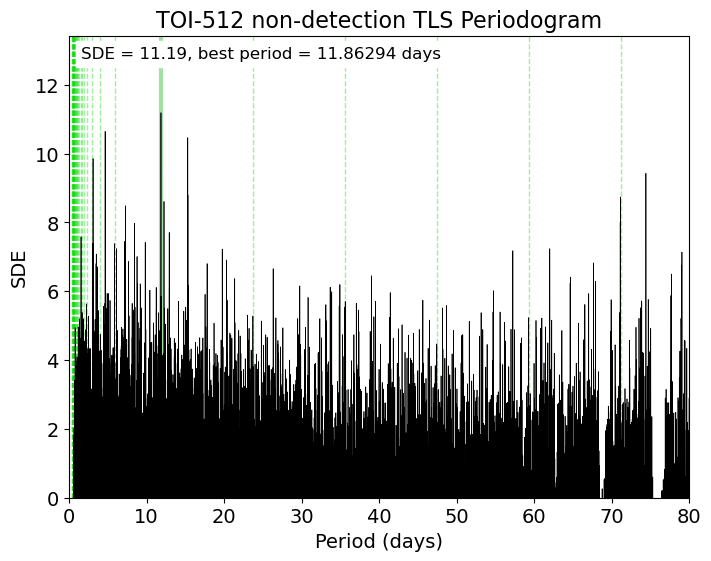

In [57]:
all_results_full = planet_search(lc_full, stellar_params, max_planets=10, sde_threshold=SDE_THRESHOLD, period_max=PERIOD_MAX,
                                 min_transits=MIN_TRANSITS, mask_mult=1.4, odd_even_sigma=ODD_EVEN_SIGMA,
                                 depth_scatter_nsig=DEPTH_SCATTER_NSIG, secondary_depth=SECONDARY_DEPTH,
                                 target=target, outdir=outdir)

## 5. Outputs

We produce the following outputs:

**Summary tables:**
- `<target>_summary.txt` — human-readable table of detected planets with periods, radii, and estimated masses.
- `<target>_report.ecsv` — machine-readable ECSV table with all TLS and PyTransit parameters.

**Light curve files (for PyOrbit):**
- `<target>_lc_pdcsap.dat` — cleaned PDCSAP photometry.
- `<target>_lc_sap_bin4h.dat` — out-of-transit SAP photometry binned to 4-hour intervals.

**PyOrbit configuration:**
- `<target>_pyorbit.yaml` — pre-populated PyOrbit YAML with TLS/PyTransit results as Gaussian priors and boundaries.

In [92]:
# Summary tables
results_table = Table(all_results_full)

human_readable_table(results_table).write(
    outdir + f'/{target.replace(" ","_").replace(".","-")}_summary.txt',
    format='ascii.fixed_width_two_line', overwrite=True
)

results_table.write(
    outdir + f'/{target.replace(" ","_").replace(".","-")}_report.ecsv',
    overwrite=True
)
print('Summary tables written.')

Summary tables written.


In [45]:
make_pyorbit_yaml(all_results_full, stellar_params, target, outdir)

PyOrbit YAML written to ./fulmar_output/TOI-512/TOI-512_pyorbit.yaml


In [88]:
# ---- Cleaned PDCSAP (detrended, used for transit search) --------------------
lc_to_dat(lc_full, 'time', 'flux', 'flux_err',
           os.path.join(outdir, f'{target.replace(" ","_").replace(".","-")}_lc_clean.dat'))
 
# ---- Normalised PDCSAP (not detrended) --------------------------------------
lc_to_dat(lc_full, 'time', 'pdcsap_flux_norm', 'pdcsap_flux_err_norm',
           os.path.join(outdir, f'{target.replace(" ","_").replace(".","-")}_lc_pdcsap_norm.dat'))
 
# ---- Normalised SAP ---------------------------------------------------------
lc_to_dat(lc_full, 'time', 'sap_flux_norm', 'sap_flux_err_norm',
           os.path.join(outdir, f'{target.replace(" ","_").replace(".","-")}_lc_sap_norm.dat'))
 
# ---- Out-of-transit mask -----------------------------------------------------
t_arr, _, _ = time_flux_err(lc_full)
intransit = np.zeros(len(t_arr), dtype=bool)
for res in all_results_full:
    intransit |= transit_mask(t_arr, res['p'], 1.4 * res['t14'], res['T0'])
 
lc_oot = lc_full[~intransit]
 
# ---- Binned out-of-transit PDCSAP (4h) --------------------------------------
lc_pdcsap_bin = bin_lc(lc_oot, 4 * u.h,
                        flux_kw='pdcsap_flux_norm',
                        flux_err_kw='pdcsap_flux_err_norm')
lc_to_dat(lc_pdcsap_bin, 'time', 'pdcsap_flux_norm', 'pdcsap_flux_err_norm',
          os.path.join(outdir, f'{target.replace(" ","_").replace(".","-")}_lc_pdcsap_norm_oot_bin4h.dat'))
 
# ---- Binned out-of-transit SAP (4h) -----------------------------------------
lc_sap_bin = bin_lc(lc_oot, 4 * u.h,
                     flux_kw='sap_flux_norm',
                     flux_err_kw='sap_flux_err_norm')
lc_to_dat(lc_sap_bin, 'time', 'sap_flux_norm', 'sap_flux_err_norm',
          os.path.join(outdir, f'{target.replace(" ","_").replace(".","-")}_lc_sap_norm_oot_bin4h.dat'))
 


Exported 48411 epochs to ./fulmar_output/TOI-512/TOI-512_lc_clean.dat
Exported 48411 epochs to ./fulmar_output/TOI-512/TOI-512_lc_pdcsap_norm.dat
Exported 48411 epochs to ./fulmar_output/TOI-512/TOI-512_lc_sap_norm.dat
Exported 410 epochs to ./fulmar_output/TOI-512/TOI-512_lc_pdcsap_norm_oot_bin4h.dat
Exported 410 epochs to ./fulmar_output/TOI-512/TOI-512_lc_sap_norm_oot_bin4h.dat
